In [ ]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

# ! pip install scikit-posthocs==0.3.7

import scikit_posthocs as sp
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores
from hbn.visualization import utils as utils
from hbn.visualization.stats import f_test

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:

def calc_ratios(df, group='DX_Subtype_Name', ratio='Sex', measure='WIAT', scale='P'):
    if group is not None:
        grouped_df = df.groupby(['score_names', group, ratio])['scores'].mean().unstack()
    else:
        grouped_df = df.groupby(['score_names',ratio])['scores'].mean().unstack()
    ratio_vals = df[ratio].unique()
    if len(ratio_vals)==2:
        grouped_df['ratio_m'] = (grouped_df[ratio_vals[0]] / grouped_df[ratio_vals[1]]) * 100
        grouped_df.loc[grouped_df['ratio_m'] < 100.0, 'ratio_m'] *= -1
        grouped_df = grouped_df.reset_index()
        grouped_df['score_names'] = grouped_df['score_names'].str.replace(f'{measure},{measure}_', '').str.replace(f'_{scale}', "")

        grouped_df = grouped_df.dropna().reset_index()
        return grouped_df
    else:
        raise ValueError(f'length of groups in {ratio} does not equal 2')


In [8]:
compare_groups = [
                  {'DX_Subtype_Name': ['ADHD-Combined Type']},
                  {'DX_Subtype_Name': ['ADHD-Inattentive Type']},
                  {'DX_Subtype_Name': ['ADHD-Hyperactive/Impulsive Type']},
                  {'DX_Subtype_Name': ['Other Specified Attention-Deficit/Hyperactivity Disorder', 'Unspecified Attention-Deficit/Hyperactivity Disorder']},
                  {'DX_ADHD': ['adhd_all_comorbidities']},
                  {'DX_ADHD': ['adhd_no_comorbidities']},
                  {'DX_Cat_Name_New': ['ADHD']},
                  {'DX_Cat_Name_New': ['Anxiety Disorders']},
                  {'DX_Cat_Name_New': ['Depressive Disorders']},
                  {'DX_Cat_Name_New': ['No Diagnosis Given']},
                  {'DX_Cat_Name_New': ['Autism Spectrum Disoder']},
                  {'DX_Cat_Name_New': ['Neurodevelopmental Disorders']}
                  ] 

### Educational Achievement

In [23]:
vis.plotting_style()

def get_wiat_data():

    # get full keys
    measure = 'WIAT'
    assessment = 'child'
    scale = 'P'
    keys = ['RC', 'Num', 'Pseudo', 'Spell', 'Word', 'LCRV', 'LCODC', 'MP']
    features = [f'{measure},{measure}_{key}_{scale}' for key in keys]

    # get data for plot
    df_wiat = pd.DataFrame()
    for group in compare_groups:
        dx_col = list(group.keys())[0]
        dx = list(group.values())[0]
        df = raw_scores.get_data(
                release='Release11_Apr2024',
                assessment=assessment, 
                cols_to_filter=['sex', 'age_round', dx_col],
                vals_to_filter=[['male', 'female'], list(np.arange(6,18)), dx],
                measure=None,
                features=features
            )
        df_wiat = pd.concat([df_wiat, df])
    
    # remap wiat columns
    map_cols = {'WIAT,WIAT_LCODC_P': 'Listening Comprehension (Oral Discourse)',
                'WIAT,WIAT_LCRV_P': 'Listening Comprehension (Receptive Vocabulary)',
                'WIAT,WIAT_MP_P': 'Math Problem Solving',
                'WIAT,WIAT_Num_P': 'Numerical Operations',
                'WIAT,WIAT_Pseudo_P': 'Pseudo-Word Decoding',
                'WIAT,WIAT_RC_P': 'Reading Comprehension',
                'WIAT,WIAT_Spell_P': 'Spelling',
                'WIAT,WIAT_Word_P': 'Word Reading'
                }

    for col in df_wiat.columns:
        try:
            df_wiat = df_wiat.rename({col: map_cols[col]}, axis=1)
            print(col)
        except:
            pass

    return df_wiat, list(map_cols.values())

def get_nih_data():
    measure = 'NIH_final'
    scale = 'Age_Corr_Stnd'
    keys = ['Card_Sort', 'Flanker', 'List_Sort', 
            'Processing', 'Picture_Vocab', 'Picture_Seq']
    assessment = 'child'

    # get full keys
    features = [f'{measure},NIH_{key}_{scale}' for key in keys]

    # get data for plot
    df_nih = pd.DataFrame()
    for group in compare_groups:
        df = raw_scores.get_data(
                release='Release11_Apr2024',
                assessment=assessment, 
                cols_to_filter=['sex', 'age_round', list(group.keys())[0]],
                vals_to_filter=[['male', 'female'], list(np.arange(6,18)), list(group.values())[0]],
                measure=None,
                features=features
            )
        df_nih = pd.concat([df_nih, df])

    # remap nih columns
    map_cols = {
                'NIH_final,NIH_Card_Sort_Age_Corr_Stnd': 'Card Sort',
                'NIH_final,NIH_Flanker_Age_Corr_Stnd': 'Flanker',
                'NIH_final,NIH_List_Sort_Age_Corr_Stnd': 'List Sort',
                'NIH_final,NIH_Processing_Age_Corr_Stnd': 'Processing Speed',
                'NIH_final,NIH_Picture_Vocab_Age_Corr_Stnd': 'Picture Vocabulary',
                'NIH_final,NIH_Picture_Seq_Age_Corr_Stnd': 'Picture Sequence',
                }

    for col in df_nih.columns:
        try:
            df_nih = df_nih.rename({col: map_cols[col]}, axis=1)
        except:
            pass

    return df_nih, list(map_cols.values())
    

def plot_data(df, feature_names, measure='WIAT', dx='DX_Cat_Name_New', dx_vals=['ADHD', 'No Diagnosis Given']):

    df = df.rename({dx: 'DX'}, axis=1)
    df = df.rename({'score_names': f'{measure} Measures'}, axis=1)

    # get unique participant data for ADHD + no diagnosis
    df_cat = df[df['DX'].isin(dx_vals)]
    df_grouped = df_cat.groupby('Identifiers').head(1)

    fig = plt.figure(figsize=(11,6))
    gs = GridSpec(2, 2, figure=fig)

    # A

    # format data to plot
    # common_features = list(set(df_grouped.columns) & set(feature_names))
    df_melt = pd.melt(df_grouped, value_vars=feature_names, 
            id_vars=['sex', 'DX', 'Identifiers']) \
            .rename(columns={'variable': f'{measure} Measures', 'value': 'scores'})

    df_melt = df_melt[df_melt['DX'].isin(dx_vals)]
    data_to_plot = df_melt.pivot_table(
            index=[f'{measure} Measures', 'DX'],  # Keep these columns as is
            columns='sex',
            values='scores',
            ).reset_index()

    ax = fig.add_subplot(gs[0, 0])
    ax = vis.scatterplot(
        df=data_to_plot, 
        ax=ax,
        hue='DX',
        x='female', 
        y='male',
        style=f'{measure} Measures',
        xlabel=f'{measure} Scores (girls)',
        ylabel=f'{measure} Scores (boys)',
        ylim=None,
        subplot='A',
        bbox_to_anchor=(.95,1)
        )

    # B
    df_mean_scores = df_melt.groupby(['Identifiers', 'sex', 'DX']).apply(lambda x: x['scores'].mean()).reset_index(name='scores')
    df_mean_scores['sex'] = df_mean_scores['sex'].map({'female': 'Girls', 'male': 'Boys'})
    ax = fig.add_subplot(gs[0, 1])
    ax = vis.barplot(
        data=df_mean_scores, 
        ax=ax,
        hue='sex',
        x='DX', 
        y='scores',
        ylabel=f'{measure} scores',
        ylim=None,
        subplot='B',
        bbox_to_anchor=(1.1,1),
        log_scale=False,
        )

    # do stats
    f_test(df_mean_scores.dropna(how='any'), dependent_col='scores', factor1_col='DX', factor2_col='sex')

    return df_mean_scores



--- Performing Two-Way ANOVA for scores by DX and sex ---
                    sum_sq      df           F        PR(>F)
C(DX)         6.211535e+04     1.0  119.796958  2.560150e-27
C(sex)        6.255244e+03     1.0   12.063993  5.220312e-04
C(DX):C(sex)  1.564378e+02     1.0    0.301709  5.828577e-01
Residual      1.418630e+06  2736.0         NaN           NaN

--- ANOVA Interpretation ---
The interaction effect between DX and sex is NOT statistically significant (p >= 0.05).
You may proceed to interpret the main effects of DX and sex.
Post-hoc tests will still be performed on combined groups for thoroughness,
but if only main effects were significant, you might consider post-hoc on main effects.

--- Performing Post-Hoc Tests (Tukey HSD) using statsmodels ---
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                  group2          meandiff p-adj   lower   upper  reject
----------------------------------------------------

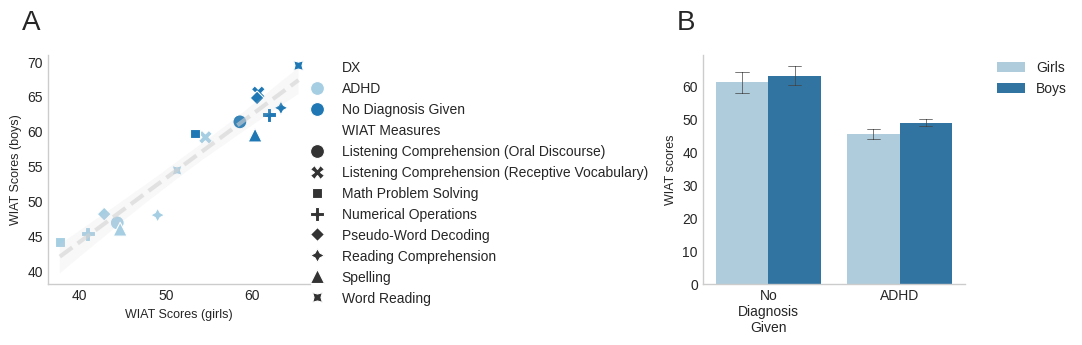

In [ ]:
# get WIAT scores
# df_wiat, features = get_wiat_data()

plot_data(df=df_wiat, feature_names=features, measure='WIAT', dx='DX_Cat_Name_New', dx_vals=['ADHD', 'No Diagnosis Given'])


--- Performing Two-Way ANOVA for scores by DX and sex ---
                    sum_sq      df         F    PR(>F)
C(DX)         5.968157e+03     2.0  5.599193  0.003753
C(sex)        4.585093e+03     1.0  8.603267  0.003390
C(DX):C(sex)  4.225187e+01     2.0  0.039640  0.961136
Residual      1.195935e+06  2244.0       NaN       NaN

--- ANOVA Interpretation ---
The interaction effect between DX and sex is NOT statistically significant (p >= 0.05).
You may proceed to interpret the main effects of DX and sex.
Post-hoc tests will still be performed on combined groups for thoroughness,
but if only main effects were significant, you might consider post-hoc on main effects.

--- Performing Post-Hoc Tests (Tukey HSD) using statsmodels ---
                              Multiple Comparison of Means - Tukey HSD, FWER=0.05                              
               group1                              group2               meandiff p-adj   lower    upper  reject
----------------------------------

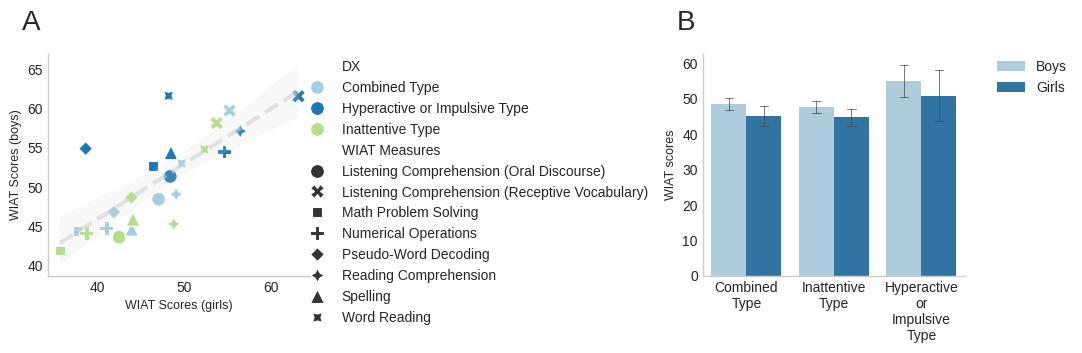

In [ ]:
# get WIAT scores
# df_wiat, features = get_wiat_data(measure='WIAT', assessment='child')

df_wiat['DX_Subtype_Name'] = df_wiat['DX_Subtype_Name'].map({'ADHD-Combined Type': 'Combined Type',
                                                            'ADHD-Inattentive Type': 'Inattentive Type',
                                                            'ADHD-Hyperactive/Impulsive Type': 'Hyperactive or Impulsive Type'})

plot_data(df=df_wiat, feature_names=features, measure='WIAT', dx='DX_Subtype_Name', dx_vals=['Combined Type', 'Inattentive Type', 'Hyperactive or Impulsive Type'])


--- Performing Two-Way ANOVA for scores by DX and sex ---
                     sum_sq      df          F        PR(>F)
C(DX)           9890.404944     1.0  63.123043  2.956844e-15
C(sex)             7.183337     1.0   0.045846  8.304744e-01
C(DX):C(sex)       1.305659     1.0   0.008333  9.272733e-01
Residual      376356.264322  2402.0        NaN           NaN

--- ANOVA Interpretation ---
The interaction effect between DX and sex is NOT statistically significant (p >= 0.05).
You may proceed to interpret the main effects of DX and sex.
Post-hoc tests will still be performed on combined groups for thoroughness,
but if only main effects were significant, you might consider post-hoc on main effects.

--- Performing Post-Hoc Tests (Tukey HSD) using statsmodels ---
                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                  group2          meandiff p-adj   lower  upper  reject
------------------------------------------------------

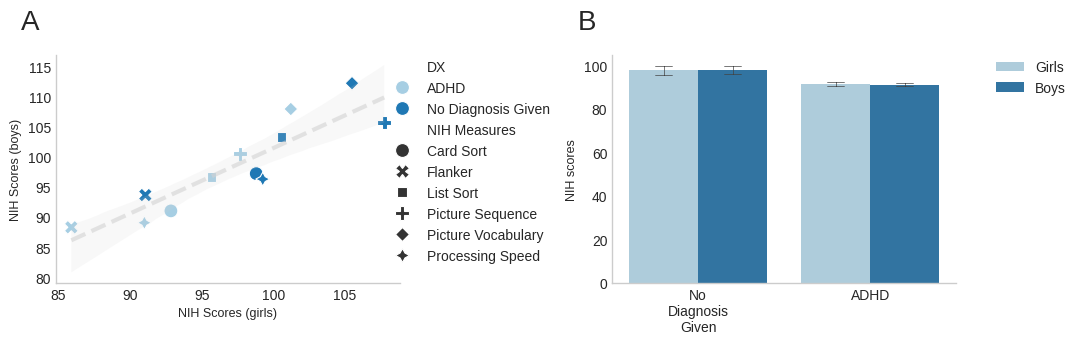

In [ ]:
# get NIH scores
# df_nih, features = get_nih_data()

plot_data(df=df_nih, feature_names=features, measure='NIH', dx='DX_Cat_Name_New', dx_vals=['ADHD', 'No Diagnosis Given'])


In [19]:
# get NIH scores
# df_nih, features = get_nih_data()

df_nih['DX_Subtype_Name'] = df_nih['DX_Subtype_Name'].map({'ADHD-Combined Type': 'Combined Type',
                                                            'ADHD-Inattentive Type': 'Inattentive Type',
                                                            'ADHD-Hyperactive/Impulsive Type': 'Hyperactive or Impulsive Type'})

plot_data(df=df_nih, feature_names=features, measure='NIH', dx='DX_Subtype_Name', dx_vals=['Combined Type', 'Inattentive Type', 'Hyperactive or Impulsive Type'])


TypeError: plot_data() got an unexpected keyword argument 'measure'

In [ ]:
# grouped_df = calc_ratios(df, group=dx, ratio='Sex', measure=measure, scale=scale)
# grouped_df['score_names'] = grouped_df['score_names'].str.replace('NIH_final,NIH_', '').str.replace('_Age_Corr', '')

# # plot
# vis.circular_barplot(df=grouped_df, values='ratio_m', labels='score_names', group=dx)